# Lesson 3.8 — 从状态策略走向多模态策略

主线是把

$$
\text{state}\,[42]\rightarrow\text{action chunk}\,[8,8]
$$

扩展为

$$
(\text{image},\ \text{language},\ \text{robot state})\rightarrow\text{action chunk}.
$$

**本课的纪律**：`action_chunk [H,8]` **冻结**在 3.7 的形态。只动输入侧。这样 3.8.6 的任何差异都只能归因于模态，而不是动作表示或 chunk 长度。

对应 `docs/roadmap_v3.md` 的 3.8。

| 阶段 | 学什么 | 动手结果 |
|---|---|---|
| **3.8.1 输入契约** | 图像、机器人状态、任务文字分别提供什么信息 | 定义一个多模态训练样本及各字段 shape |
| **3.8.2 时间对齐** | 哪张图像与 $o_t,a_t$ 配对；相机帧率与控制频率不同怎么办 | 检查同一 episode 内的时间戳和帧对应关系 |
| 3.8.3 可观测性 | 42 维 state 中哪些来自仿真真值，哪些真机可获得 | 分出 proprioception 与需要视觉估计的信息 |
| 3.8.4 语言条件 | 指令如何表示任务目标；模型何时真的需要读取语言 | 比较固定指令与多个不同指令 |
| 3.8.5 最小融合模型 | 图像编码器、状态 MLP、文字编码器如何合成策略输入 | 保留 H=8 输出，跑通一次前向与训练 |
| 3.8.6 消融与评估 | 各模态究竟带来什么 | 比较 state / image+state / image+state+language |
| 3.8.7 接到 VLA | 视觉语言表示如何连接动作生成 | 画清数据到 action chunk 的接口 |

**本 notebook 覆盖 3.8.1 与 3.8.2。**

## 3.8.1 输入契约：一个多模态训练样本

3.7 的样本是

$$
(o_t,\ [a_t,\dots,a_{t+H-1}]),\qquad t=0\dots T-H
$$

3.8 的样本只把**输入侧**换掉：

```text
sample(e, t)   t = 0 .. T-H

  image         [3, 128, 128]   uint8      L=1（本课隔离模态变量，历史留给 3.6 的决策）
  language_ids  [T_txt]         int64      指令 token ids
  proprio       [25]            float32    qpos9 + qvel9 + tcp_pose7
  task_goal     [3]             float32    goal_pos，来源 = 任务规格，不是传感器
  action_chunk  [8, 8]          float32    与 3.7 完全一致
```

### 契约被三个已确认的事实约束

**事实 1 — 仓库原本没有任何图像。** 三个 HDF5 只有 `actions` / `observations` / `rewards`，因为 `scripts/generate_expert_demo.py` 写死了 `OBS_MODE = "state"`。图像从未被请求过。

**事实 2 — 这台机器能渲染 RGB，且渲染不扰动物理。** `obs_mode="rgb"` 返回 `sensor_data.base_camera.rgb (1,128,128,3) uint8`。把 `state` 环境与 `rgb` 环境用**相同动作同步推进 74 步**，从 rgb 环境重建的 42 维与 `obs["state"]` 的最大差是 `0.000e+00` —— 既验证了重建函数，也说明渲染器不参与物理。

**事实 3 — 目标点（goal）在图像里看不见。** `pick_cube.py` 建完 `goal_site` 后执行 `self._hidden_objects.append(self.goal_site)`；ManiSkill 在别处把 `_hidden_objects` 注释为"让 Actor 不出现在视觉观测里"。而 `pick_cube.py` 的 docstring 却说它"marked by a green sphere"——**文档错、代码对**。把 goal 的三维位置投影到像素 `(63.7, 61.1)`，那里只有机械臂本体。

> **这直接推出 3.8 的第一个陷阱**：PickCube 的成功判据是 $\lVert\text{goal}-\text{cube}\rVert\le0.025$。**如果把 `goal_pos` 从 state 里删掉以换取"可部署"，而指令只是固定的 `"pick up the cube"`，那么 (image, language, proprio) 里没有任何信息告诉策略该把方块放到哪里——任务不可解，而 loss 曲线完全看不出来。** 这就是 `task_goal` 必须作为独立一路输入留在契约里的理由。

### 所以本 notebook 读的是哪个文件

**不是** `expert_episodes.h5`（3.7 用的那个），而是一个**新采集的文件**：

| 文件 | 内容 | 谁在用 |
|---|---|---|
| `datasets/pickcube/expert_episodes.h5` | `actions` / `observations` / `rewards`，**无图像** | 3.7 及以前 |
| `datasets/pickcube/expert_episodes_rgb.h5` | 同上 **+ `images (T+1, 128, 128, 3) uint8`** | **本课** |

**图像不可能是从旧文件"提取"出来的**——42 维 state 里没有像素，图像只能来自渲染，而旧文件的采集脚本写死了 `OBS_MODE = "state"`，图像从未被请求过。

新文件是**重新采集**的结果：同一个 planner、同一批 seed（0–4）、同一个控制模式 `pd_joint_pos`，只是在 `obs_mode="rgb"` 下再跑一次：

```bash
python scripts/generate_expert_demo.py --seeds 0 1 2 3 4 \
    --obs-mode rgb+state --out datasets/pickcube/expert_episodes_rgb.h5 --overwrite
```

用 `rgb+state` 而不是纯 `rgb`，是因为**组合模式是原生支持的**：ManiSkill 把 `obs_mode` 解析成结构（`parse_obs_mode_to_struct`），组合模式下 `obs["state"]`（42 维）与相机图像来自**同一个 `env.step`**。collector 早期版本曾手写重建 42 维（`build42`），现已删除——原生路径少一处"重新实现 ManiSkill 扁平化顺序"的维护面。删除前后重新采集的两个文件，**图像逐字节相同**。

**但它不是"另一套数据"，而是同 5 条轨迹 + 一个模态。** 三个数组全部逐位相同：

| episode | `observations` | `actions` | `rewards` |
|---|:--:|:--:|:--:|
| 000000–000004 | True ×5 | True ×5 | True ×5 |

所以本课的图像坐落在 3.1–3.7 一直用的那条轨迹上——这就是 §3.8.2 里"对齐是构造性的"那句话的依据。

**为什么不直接给旧文件加一列图像？** 因为仓库有一条硬规则：**不许静默改变已有数据的语义**。就地写入会改变旧文件的哈希（`expert_episodes_delta.h5` 的 provenance 里记着它的 `sha256`），而且"改没改过"将无法从文件内容判断。新文件 + 逐位相同的验证，让"两个文件是不是同一条轨迹"这个问题有一个确定的答案。

### 42 维的可部署性分类

下标来自 `notebooks/lesson_1/1.1_state_and_observation.ipynb` 的**实测验证**（不是字段名的直觉顺序——`is_grasped` 在索引 18，夹在 `qvel` 与 `tcp_pose` 之间）：

| 切片 | 字段 | 维度 | 类别 | 真机来源 |
|---|---|---:|---|---|
| `[0:9]` | `agent.qpos` | 9 | deployable | 关节编码器 |
| `[9:18]` | `agent.qvel` | 9 | deployable（带噪声） | 编码器差分，噪声被放大 $1/\Delta t$ |
| `[18:19]` | `extra.is_grasped` | 1 | **sensor-estimable** | 夹爪宽度 / 力矩 / 视觉 |
| `[19:26]` | `extra.tcp_pose` | 7 | deployable（依赖标定） | 正运动学 |
| `[26:29]` | `extra.goal_pos` | 3 | **task-provided** | 任务规格 / 指令 |
| `[29:36]` | `extra.obj_pose` | 7 | **vision-estimable** | 视觉位姿估计 |
| `[36:39]` | `extra.tcp_to_obj_pos` | 3 | derived | 由上面两者算出 |
| `[39:42]` | `extra.obj_to_goal_pos` | 3 | derived | 由上面两者算出 |

契约据此把输入切成四路：`proprio [25]`（$[0:9]\cup[9:18]\cup[19:26]$）、`task_goal [3]`、`image`（负责 `obj_pose` 与 `is_grasped` 的估计）、`language`（负责任务身份，3.8.4 再看它能否接管 goal）。

**被排除的 14 维**（`is_grasped`、`obj_pose`、`tcp_to_obj`、`obj_to_goal`）**不作为输入**——它们是**待估计量**，是视觉要承担的那部分。

In [1]:
# 3.8.1 契约断言：先把 "一个样本是什么" 钉死，再构造它
import h5py
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RGB_H5 = PROJECT_ROOT / "datasets" / "pickcube" / "expert_episodes_rgb.h5"
OBS_DIM, ACTION_DIM = 42, 8
IMAGE_HW, CHANNELS = 128, 3
H = 8                                   # 与 3.7 一致，动作侧冻结

# Block order verified in lesson 1.1 by np.allclose against obs_mode="state".
PROPRIO_SLICES = ((0, 9), (9, 18), (19, 26))      # qpos, qvel, tcp_pose
TASK_GOAL_SLICE = (26, 29)                        # goal_pos
EXCLUDED_SLICES = ((18, 19), (29, 36), (36, 39), (39, 42))

with h5py.File(RGB_H5, "r") as f:
    attrs = {k: f.attrs[k] for k in ("obs_mode", "image_camera", "image_shape",
                                     "image_dtype", "control_mode",
                                     "transition_schema_version", "control_freq_hz")}
    assert attrs["obs_mode"] == "rgb", attrs["obs_mode"]
    assert attrs["control_mode"] == "pd_joint_pos", attrs["control_mode"]
    assert attrs["transition_schema_version"] == 2, attrs["transition_schema_version"]
    assert list(attrs["image_shape"]) == [IMAGE_HW, IMAGE_HW, CHANNELS], attrs["image_shape"]
    assert attrs["image_dtype"] == "uint8", attrs["image_dtype"]

    episodes = []
    for name in sorted(f.keys()):
        g = f[name]
        obs, act, img = g["observations"][:], g["actions"][:], g["images"][:]
        assert obs.shape[1] == OBS_DIM, (name, obs.shape)
        assert act.shape[1] == ACTION_DIM, (name, act.shape)
        assert img.shape == (obs.shape[0], IMAGE_HW, IMAGE_HW, CHANNELS), (name, img.shape)
        assert obs.shape[0] == act.shape[0] + 1, (name, obs.shape[0], act.shape[0])
        assert img.dtype == np.uint8, img.dtype
        episodes.append(dict(name=name, all_state=obs, state=obs[:-1], next_state=obs[1:],
                             action=act, image=img, seed=int(g.attrs["seed"]),
                             success=bool(g.attrs["success"])))

print(f"{len(episodes)} episodes | obs_mode={attrs['obs_mode']} | "
      f"camera={attrs['image_camera']} | control {attrs['control_freq_hz']} Hz")
print("T per episode  :", [len(e["action"]) for e in episodes])
print("observations   :", [e["all_state"].shape[0] for e in episodes], "(= T+1)")
print("images         :", [e["image"].shape[0] for e in episodes], "(= T+1)")
print("image dtype    :", episodes[0]["image"].dtype,
      f"| {episodes[0]['image'][0].nbytes:,} bytes/frame")
print("all episodes successful:", all(e["success"] for e in episodes))
print()
print("contract assertions passed")


5 episodes | obs_mode=rgb | camera=base_camera | control 20 Hz
T per episode  : [74, 74, 50, 86, 76]
observations   : [75, 75, 51, 87, 77] (= T+1)
images         : [75, 75, 51, 87, 77] (= T+1)
image dtype    : uint8 | 49,152 bytes/frame
all episodes successful: True

contract assertions passed


上面这个 cell 只用了三句 `assert` 就把"一个样本的边界"钉死了：**图像数量 = 观测数量 = 动作数量 + 1**。少了最后那句，`(75,128,128,3)` 和 `(75,42)` 这种"数量对但配错了"的情况就会溜过去——这正是 Lesson 2 那个 post-action 观测缺陷的形状。

In [2]:
# 构造一个真实样本，而不是描述它
TASK_STRING = "pick up the cube"     # 仓库里唯一的指令来源：LeRobot meta/tasks.parquet

# 占位 tokenizer：按空白切词。真实 tokenizer（BPE 等）以后再替换；
# 现在要的是把 language 这一路变成有确定 shape 的字段。
VOCAB = {"<pad>": 0, "<bos>": 1, "<eos>": 2}
for word in TASK_STRING.split():
    VOCAB.setdefault(word, len(VOCAB))
language_ids = ([VOCAB["<bos>"]]
                + [VOCAB[w] for w in TASK_STRING.split()]
                + [VOCAB["<eos>"]])


def proprio_of(state_row):
    return np.concatenate([state_row[lo:hi] for lo, hi in PROPRIO_SLICES]).astype(np.float32)


def build_sample(ep, t, H=H):
    assert 0 <= t <= len(ep["action"]) - H, f"t={t} leaves no room for H={H}"
    return dict(
        image=ep["image"][t],                                    # [128,128,3] uint8
        language_ids=np.asarray(language_ids, dtype=np.int64),   # [T_txt]
        proprio=proprio_of(ep["all_state"][t]),                  # [25]
        task_goal=ep["all_state"][t][TASK_GOAL_SLICE[0]:TASK_GOAL_SLICE[1]].astype(np.float32),
        action_chunk=ep["action"][t:t + H],                      # [8,8]
    )


sample = build_sample(episodes[0], 0)
print(f"{'field':<14} {'shape':<18} {'dtype':<9} source")
print("-" * 74)
src = {"image": "camera at step t", "language_ids": "task string",
       "proprio": f"state{list(PROPRIO_SLICES)}", "task_goal": f"state{TASK_GOAL_SLICE}",
       "action_chunk": f"actions[t:t+{H}]"}
for k, v in sample.items():
    print(f"{k:<14} {str(v.shape):<18} {str(v.dtype):<9} {src[k]}")

print()
print(f"language : {TASK_STRING!r} -> {len(sample['language_ids'])} tokens "
      f"{sample['language_ids'].tolist()}")
print(f"task_goal: {np.round(sample['task_goal'], 4)}")
print(f"excluded from the input: slices {list(EXCLUDED_SLICES)} "
      f"= {sum(hi - lo for lo, hi in EXCLUDED_SLICES)} dims (to be estimated from the image)")

assert sample["image"].shape == (IMAGE_HW, IMAGE_HW, CHANNELS)
assert sample["proprio"].shape == (25,)
assert sample["task_goal"].shape == (3,)
assert sample["action_chunk"].shape == (H, ACTION_DIM)
assert 25 + 3 + sum(hi - lo for lo, hi in EXCLUDED_SLICES) == OBS_DIM
print()
print("contract assertions passed")
print(f"action_chunk is byte-for-byte the same contract as 3.7: {sample['action_chunk'].shape}")


field          shape              dtype     source
--------------------------------------------------------------------------
image          (128, 128, 3)      uint8     camera at step t
language_ids   (6,)               int64     task string
proprio        (25,)              float32   state[(0, 9), (9, 18), (19, 26)]
task_goal      (3,)               float32   state(26, 29)
action_chunk   (8, 8)             float32   actions[t:t+8]

language : 'pick up the cube' -> 6 tokens [1, 3, 4, 5, 6, 2]
task_goal: [ 0.0268 -0.002   0.2889]
excluded from the input: slices [(18, 19), (29, 36), (36, 39), (39, 42)] = 14 dims (to be estimated from the image)

contract assertions passed
action_chunk is byte-for-byte the same contract as 3.7: (8, 8)


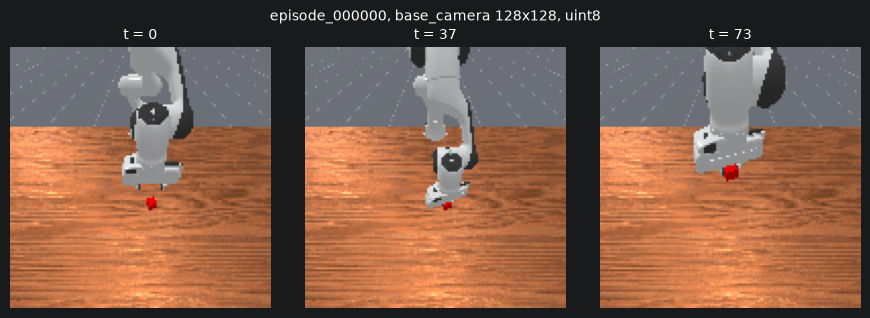

image 提供的信息:
  - obj_pose       : 方块可见（红色小方块），但只有很少的像素
  - is_grasped     : 可从夹爪与方块的关系推断
  - goal_pos       : 不可见（goal_site 在 _hidden_objects 里，不渲染）
  - 任务身份        : 不可见（由 language 提供）

所以 image 单独不足以决定 action：goal 只能来自 task_goal 或 language。


In [4]:
# 看一眼 image 这一路到底提供了什么
%matplotlib inline
import matplotlib.pyplot as plt

ep = episodes[0]
T = len(ep["action"])
show_at = [0, T // 2, T - 1]

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, t in zip(axes, show_at):
    ax.imshow(ep["image"][t])
    ax.set_title(f"t = {t}", fontsize=10)
    ax.axis("off")
fig.suptitle("episode_000000, base_camera 128x128, uint8", fontsize=10)
plt.tight_layout()
plt.show()

print("image 提供的信息:")
print("  - obj_pose       : 方块可见（红色小方块），但只有很少的像素")
print("  - is_grasped     : 可从夹爪与方块的关系推断")
print("  - goal_pos       : 不可见（goal_site 在 _hidden_objects 里，不渲染）")
print("  - 任务身份        : 不可见（由 language 提供）")
print()
print("所以 image 单独不足以决定 action：goal 只能来自 task_goal 或 language。")


## 3.8.2 时间对齐

### 对齐规则

| 关系 | 本课的定义 |
|---|---|
| `images[k]` ↔ `observations[k]` | **同一次 `env.step` 之后的同一步**，下标一一对应 |
| 帧数 | **T+1**，与 `observations[T+1]` 完全一致（含 reset 帧 `o_0`） |
| 训练配对 | `sample(e,t)` 用 `image[t]` 与 `action_chunk = actions[t:t+H]` |

**为什么在 sim 里这是无歧义的**：控制频率 20 Hz，collector 在**每个控制步渲染一帧**，所以不存在"相机帧率与控制频率不同"的问题——渲染帧率就等于控制频率。

**但这个仓库的数据里没有时间戳。** `timestamp_source = derived_not_measured`，而 episode 属性里只有 `seed` / `num_actions` / `num_observations` / 三个成功标志，**没有逐帧时间**。所以上面的对齐是**按 index 成立**的，不是按时间成立的。在 sim 里这够用；在真机上不够用：

$$
\text{相机 30 fps} \ne \text{控制 20 Hz} \quad\Longrightarrow\quad \text{必须靠时间戳配对}
$$

而且这个仓库已经有一个先例：控制频率是 **20 Hz**，但 LeRobot 侧声明的 `fps` 是 **50**（由合成时间戳推断而来），时间轴被压缩 **2.5×**。图像一旦进入 dataset，这个缺陷会被放大——因为图像与动作的配对错误在 loss 上同样看不出来。

In [6]:
# 3.8.2 对齐检查
print("=== index-level alignment (all episodes) ===")
print(f"{'episode':>16} {'T':>3} {'obs':>4} {'images':>7} {'img==obs':>9} {'paired':>7}")
ok_all = True
for ep in episodes:
    n = len(ep["action"])
    same = ep["image"].shape[0] == ep["all_state"].shape[0]
    ok_all &= same and ep["image"].shape[0] == n + 1
    print(f"{ep['name']:>16} {n:>3} {ep['all_state'].shape[0]:>4} "
          f"{ep['image'].shape[0]:>7} {str(same):>9} {'yes':>7}")
assert ok_all, "image/observation counts disagree"
print()
print("images[k] and observations[k] come from the same env.step, so the pairing is")
print("index-based. Verified at collection time in two independent ways:")
print("  1. the collector records both from the same observation dict, and asserts")
print("     len(images) == len(observations);")
print("  2. the 42-d state block was compared against the existing state-only file and")
print("     is bit-exact in all 5 episodes, so the images sit on the same trajectory")
print("     that lessons 3.1-3.7 used.")
print()
print("=== timestamps: what the data does NOT contain ===")
with h5py.File(RGB_H5, "r") as f:
    print("  root attrs timestamp_source :", f.attrs.get("timestamp_source"))
    print("  root attrs control_freq_hz  :", f.attrs.get("control_freq_hz"))
    print("  per-episode attrs           :", sorted(f["episode_000000"].attrs.keys()))
print()
print("=> there is no per-frame timestamp. Alignment here is by INDEX, not by time.")
print()
print("=== and the known time-axis defect, now relevant to images ===")
print("  real control rate      : 20 Hz  -> 0.05 s per step")
print("  declared LeRobot fps   : 50     -> 0.02 s per step  (inferred from synthetic stamps)")
print("  ratio                  : 2.5x compression of the time axis")
print("  consequence for 3.8    : an image/action pairing error is invisible in the loss")


=== index-level alignment (all episodes) ===
         episode   T  obs  images  img==obs  paired
  episode_000000  74   75      75      True     yes
  episode_000001  74   75      75      True     yes
  episode_000002  50   51      51      True     yes
  episode_000003  86   87      87      True     yes
  episode_000004  76   77      77      True     yes

images[k] and observations[k] come from the same env.step, so the pairing is
index-based. Verified at collection time in two independent ways:
  1. the collector records both from the same observation dict, and asserts
     len(images) == len(observations);
  2. the 42-d state block was compared against the existing state-only file and
     is bit-exact in all 5 episodes, so the images sit on the same trajectory
     that lessons 3.1-3.7 used.

=== timestamps: what the data does NOT contain ===
  root attrs timestamp_source : derived_not_measured
  root attrs control_freq_hz  : 20
  per-episode attrs           : ['is_obj_placed', 'is_

**3.8.2 的结论**：在 sim 里，图像与动作的对齐**按 index 就是准确的**，而且已经被两种独立方式验证（collector 内断言 + state 块与既有文件逐位相同）。但**数据里没有逐帧时间戳**，所以这份对齐无法回答真机上"相机 30 fps、控制 20 Hz 时哪张图配哪一步"。这一条要作为契约缺口记下来，等真机数据进入时补时间戳。

## 小结

1. **样本契约**：`image [3,128,128]` + `language_ids [T_txt]` + `proprio [25]` + `task_goal [3]` → `action_chunk [8,8]`。**动作侧一个字节都没改**，这是 3.8.6 能做归因的前提。
2. **`task_goal` 必须独立成一路**：goal 在图像里不可见（源码：`_hidden_objects`），指令里也不含它，所以把它从 state 删掉会让任务不可解——而 loss 看不出来。
3. **被排除的 14 维是"待估计量"**，不是"不存在的量"：`obj_pose` 与 `is_grasped` 要靠视觉估计，`tcp_to_obj` 与 `obj_to_goal` 由几何算出。
4. **对齐按 index 成立、按时间是空白**：sim 里渲染帧率 = 控制频率所以无歧义；真机上必须补时间戳，而仓库现有的 20 Hz vs 声明 50 fps 缺陷会放大这个问题。
5. **语言目前只是占位**：全仓库唯一的指令是 `"pick up the cube"`，且它没有存在 HDF5 里（只在 LeRobot 的 `tasks.parquet`）。3.8.4 要比较不同指令，必须先把 instruction 字段加进数据。

## 自检

1. 为什么 `action_chunk` 的形状在本课必须保持不变？如果同时改了 H，3.8.6 的结论会变成什么无法解释的东西？
2. `goal_pos` 为什么不能光靠图像？给出源码级的理由，并说明删掉它之后 loss 会怎样（以及为什么这很危险）。
3. `proprio [25]` 里为什么**不含** `is_grasped` 和 `obj_pose`，却含 `qvel`？后者的"可部署"有什么附加代价？
4. 本课的对齐是"按 index"还是"按时间"？为什么在 sim 里这没问题，而真机上不行？
5. 如果相机 30 fps、控制 20 Hz，你会怎么定义"哪个图像配 $o_t$"？需要数据里有什么才能做到？

## 自检：答案

（学习者自己的回答；`> 补正` 是批注。）

**1. 为什么 `action_chunk` 的形状必须保持不变？**

> 我们无法说明加入了 image 能改变什么。

> **补正**：方向对。精确地说，改 $H$ 会**同时动三个量**：目标长度（8 个数 → 64 个数）、参数量（$H=1$ 的 23,048 → $H=8$ 的 30,272，**+31.3%**），以及**样本集**（$H=1$ 有 360 个起点，$H=8$ 只有 325 个）。所以不是"多一个变量"，是一次动三个。
>
> 更要紧的是它会**作废 3.7 刚建立的"哪个量才可比"的规则**：$H=8$ 的总 MSE 平均在 64 个数上、$H=1$ 平均在 8 个数上，**本身不可比**（3.7 §6 的结论：唯一公平的量是 $h=0$）。改 $H$ 等于把那套可比性论证重做一遍。
>
> 一句话：**3.8.6 是输入模态的消融，只有在输出侧固定时才成立。**

**2. `goal_pos` 为什么不能光靠图像？**

> 目标位置虽然存在于 simulator state 中，但这个 goal marker 被作为 hidden object 处理；你不能假设 RGB 摄像头能够看到这个绿色目标球。PickCube 的 `_get_obs_extra()` 因此会显式把 `goal_pos` 放进 observation，而 `obj_pose` 等 simulator ground truth 则只在 state observation 中额外加入。

> **补正**：源码理由完全正确，而且**这里抓到了一个连 notebook 都没写出的细节**——`_get_obs_extra()` 里 `is_grasped` / `tcp_pose` / `goal_pos` 在**无条件**部分，而 `obj_pose` / `tcp_to_obj_pos` / `obj_to_goal_pos` 在 `if "state" in self.obs_mode` 的**条件**部分。这个划分本身有含义：`goal_pos` 是**任务量**（该放到哪），`obj_pose` 是**感知量**——所以前者与 `obs_mode` 无关地暴露，后者只在 state 模式下给真值。这与契约里的分类（task-provided vs vision-estimable）完全一致。
>
> **缺的那一半——loss 会怎样**：会**先正常下降，然后卡住**（模型学得会 reach / grasp，那部分不依赖 goal），平台高度等于条件方差——正是 3.5 的 partial observability 结果。所以它**看起来像欠拟合**，会被误判为容量或数据不足。闭环上其实看得出来（方块被拿到**平均目标位置**），但 3.7 的 policy 本来就 `0/5`，两种失败混在一起无法区分。**危险在于诊断被掩盖。**
>
> **由这句话触发的一个修正**：`if "state" in self.obs_mode` 这个条件说明 `obs_mode` 支持**组合**。实测 `obs_mode="rgb+state"` 原生可用，一次返回 `obs["state"]`（42 维）与图像。所以 collector 里那 20 行手写重建（`build42`）是多余的，已删除并改用 `rgb+state`。见 §3.8.1 末尾的数据来源小节。

**3. `proprio` 为什么不含 `is_grasped` 和 `obj_pose`，却含 `qvel`？**

> 因为这里定义的 proprio 不是"所有有用的信息"，而是：机器人自身在真机上原则上能够获得的内部状态。需要额外处理：velocity estimator / filter；准确 timestamp；与 image/action 同步；robot driver 与 simulator 的单位/定义一致；filtering latency；sim-to-real distribution mismatch。**deployable 不等于 free。**

> **补正**：不需要补正，而且比 notebook 里的说法更全。你列的**每一条仓库里都已经有先例**，不是假想：
>
> | 说的代价 | 仓库里的现成证据 |
> |---|---|
> | velocity estimator / filter | 3.5 已推导：差分把观测噪声放大 $1/\Delta t$ |
> | 准确 timestamp | 20 Hz 控制 vs 声明 50 fps |
> | 与 image / action 同步 | §3.8.2 |
> | driver 与 simulator 单位/定义一致 | Action Specification 那节的 delta vs absolute、rad vs normalized |
> | sim-to-real distribution mismatch | 专门的 Sim-to-Real 一节 |
>
> "deployable ≠ free" 这句话值得留着。

**4. 本课的对齐是"按 index"还是"按时间"？**

> 目前是 index；真机上采样的频率可能会不相同。

> **补正**：对，但漏了两个更锋利的点。
>
> 1. **这份数据里根本没有时间戳。** `timestamp_source = derived_not_measured`，episode 属性只有 `seed` / `num_actions` / `num_observations` / 三个成功标志。所以"按时间对齐"在这里**做不到**，不是"暂时不用做"。
> 2. **sim 里就已经有一条错的时间轴**：控制 20 Hz、LeRobot 侧声明 50 fps → **2.5× 压缩**。所以问题不只是"真机可能不同"，而是"这份数据的时间轴本来就有已知缺陷，图像会把它放大"。
> 3. 补一句 sim 里为什么没问题：**每个控制步渲染一次 → 渲染帧率就等于控制频率**，index 与 time 重合。

**5. 相机 30 fps、控制 20 Hz 时，哪个图像配 $o_t$？**

> 选择 control step 发生之前最近的一张 camera frame。

> **补正**：规则本身正确，而且**因果安全**——"之前最近"不会取到未来帧（"最近的帧"就可能取到，那是另一种规则）。形式化：
>
> $$\text{frame}(s)=\arg\max\{\,f:\ t_{\text{frame}}(f)\le t_{\text{step}}(s)\,\}$$
>
> 这是标准的 **sample-and-hold**。但题目还问了"需要数据里有什么才能做到"，答案是：**(a) 每个控制步的时间戳；(b) 每帧图像的时间戳** —— 这两样现在都没有。
>
> 而且这个规则有一个必须记录的性质：图像与动作之间的延迟在 $[0,\ 1/\text{fps}_{\text{cam}}]$ 内变化。30 fps 相机 + 20 Hz 控制 → 平均 **1.5 个控制步才有一帧新图**，所以相邻样本会**复用同一张图**。这意味着 **"$L$ 帧图像"里可能出现重复帧，实际时间跨度小于 $L\times$ 控制周期**。